<a href="https://colab.research.google.com/github/YashodipYP/TelcoChurnEDAandQA/blob/main/TelcoChurnEDAandQA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
df.head(5)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors = 'coerce')
print(f"Number of hidden missing values: {df['TotalCharges'].isnull().sum()}")
df.info()

Number of hidden missing values: 11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperl

In [6]:
keep_cols = ['SeniorCitizen', 'tenure', 'Contract', 'PaperlessBilling',
             'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
df_churn = df[keep_cols].copy()
df.dropna(inplace=True)

In [7]:
df_churn['target'] = df_churn['Churn'].map({'Yes':1, 'No':0})

Company's Baseline Churn Rate: 26.5%


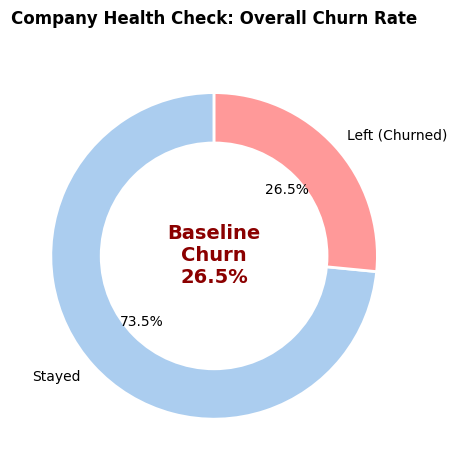

In [8]:
baseline = df_churn['target'].mean()
print(f"Company's Baseline Churn Rate: {baseline:.1%}")


churn_counts = df_churn['target'].value_counts()
colors = ['#abcdef', '#ff9999']
plt.pie(churn_counts, labels=['Stayed', 'Left (Churned)'],
        autopct='%1.1f%%', startangle=90, colors=colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.text(0, 0, f"Baseline\nChurn\n{baseline:.1%}",
         ha='center', va='center', fontsize=14, fontweight='bold', color='darkred')

plt.title("Company Health Check: Overall Churn Rate", pad=20, fontweight='bold')
plt.tight_layout()
plt.show()


In [9]:
low_bills = df_churn[df_churn['MonthlyCharges']<30]['target'].mean()
high_bills = df_churn[df_churn['MonthlyCharges']>90]['target'].mean()
print(f"Low Bills Churn: {low_bills:.1%}")
print(f"High Bills Churn: {high_bills:.1%}")

Low Bills Churn: 9.8%
High Bills Churn: 32.8%


/tmp/ipykernel_8743/1151268536.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Billing Group', y='Churn Rate', data=money_test_df, palette='Purples_r')


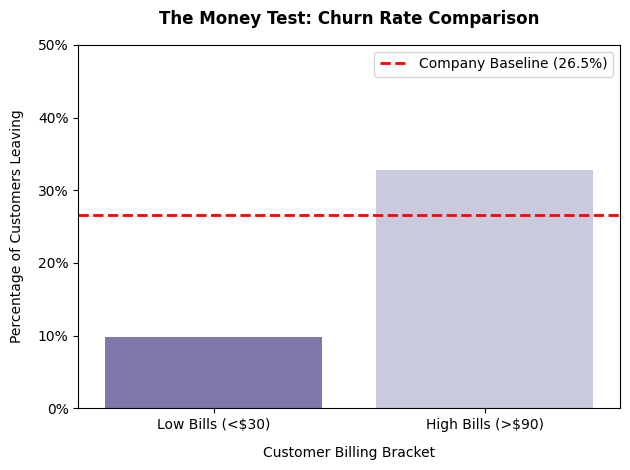

In [10]:
import seaborn as sns
money_test_df = pd.DataFrame({
    'Billing Group': ['Low Bills (<$30)', 'High Bills (>$90)'],
    'Churn Rate': [low_bills, high_bills]
})
sns.barplot(x='Billing Group', y='Churn Rate', data=money_test_df, palette='Purples_r')

plt.axhline(baseline, color='red', linestyle='--', linewidth=2, label=f"Company Baseline ({baseline:.1%})")
plt.title("The Money Test: Churn Rate Comparison", pad=15, fontweight='bold')
plt.xlabel("Customer Billing Bracket", labelpad=10)
plt.ylabel("Percentage of Customers Leaving", labelpad=10)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.ylim(0, 0.50)
plt.legend()
plt.tight_layout()


plt.show()

In [11]:
new_customers = df_churn[df_churn['tenure'] < 6]['target'].mean()
old_customers = df_churn[df_churn['tenure'] > 24]['target'].mean()

print(f"Churn rate for New Customers (≤ 6 months): {new_customers:.1%}")
print(f"Churn rate for Veterans (> 2 years): {old_customers:.1%}")

Churn rate for New Customers (≤ 6 months): 54.3%
Churn rate for Veterans (> 2 years): 14.0%


/tmp/ipykernel_8743/948912861.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer Stage', y='Churn Rate', data=tenure_test_df, palette='Oranges_r')


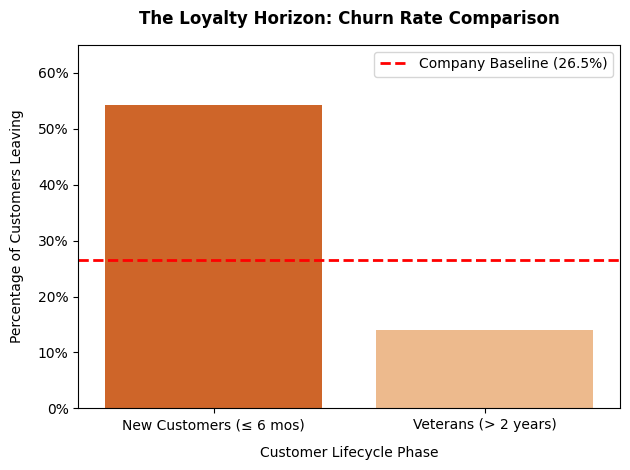

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

tenure_test_df = pd.DataFrame({
    'Customer Stage': ['New Customers (≤ 6 mos)', 'Veterans (> 2 years)'],
    'Churn Rate': [new_customers, old_customers]
})

sns.barplot(x='Customer Stage', y='Churn Rate', data=tenure_test_df, palette='Oranges_r')
plt.axhline(baseline, color='red', linestyle='--', linewidth=2, label=f"Company Baseline ({baseline:.1%})")

plt.title("The Loyalty Horizon: Churn Rate Comparison", pad=15, fontweight='bold')
plt.xlabel("Customer Lifecycle Phase", labelpad=10)
plt.ylabel("Percentage of Customers Leaving", labelpad=10)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.ylim(0, 0.65)
plt.legend()
plt.tight_layout()

plt.show()

In [13]:

print(df_churn.groupby('Contract')['target'].mean().sort_values(ascending=False))

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: target, dtype: float64


/tmp/ipykernel_8743/869693587.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contract', y='target', data=contract_data, palette='Blues_r')


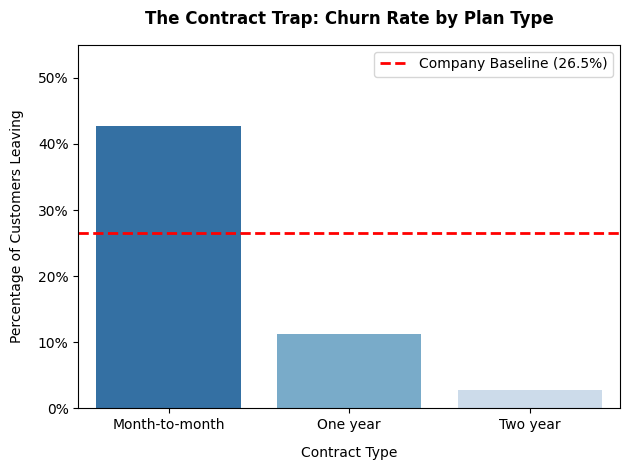

In [14]:

contract_data = df_churn.groupby('Contract')['target'].mean().sort_values(ascending=False).reset_index()

sns.barplot(x='Contract', y='target', data=contract_data, palette='Blues_r')
plt.axhline(baseline, color='red', linestyle='--', linewidth=2, label=f"Company Baseline ({baseline:.1%})")

plt.title("The Contract Trap: Churn Rate by Plan Type", pad=15, fontweight='bold')
plt.xlabel("Contract Type", labelpad=10)
plt.ylabel("Percentage of Customers Leaving", labelpad=10)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.ylim(0, 0.55)
plt.legend()
plt.tight_layout()

plt.show()

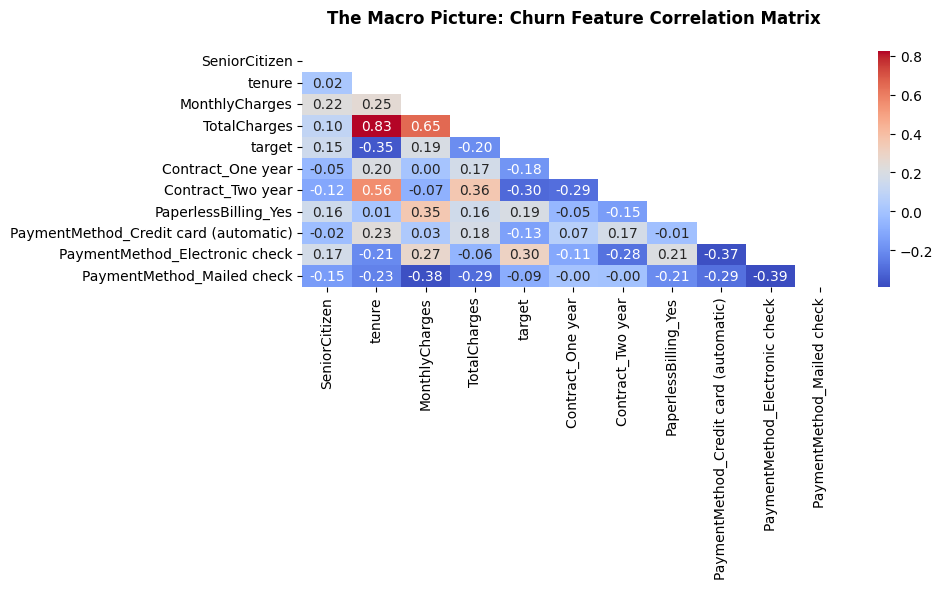

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_numeric = pd.get_dummies(df_churn.drop(columns=['Churn']), drop_first=True)

plt.figure(figsize=(10, 6))

sns.heatmap(df_numeric.corr(), annot=True, fmt=".2f", cmap='coolwarm', mask=mask, cbar=True)

plt.title("The Macro Picture: Churn Feature Correlation Matrix", pad=20, fontweight='bold')
plt.tight_layout()

plt.show()

1. The Company Baseline (The Starting Benchmark)
The Final Metric: 26.5%

The Business Meaning: Out of any random group of 100 customers, roughly 26 to 27 will pack their bags and leave the company. This is the baseline number we beat.

2. The Money Test:-
Low Bills (<$30) Churn Rate: 9.8%

High Bills (>$90) Churn Rate: 32.8%

The Strategic Takeaway: Low-priced accounts are highly stable because customers barely notice the small monthly expense. High-priced premium accounts are clear flight risks, surging well past the baseline. Because these premium accounts bring in the most revenue, losing them hurts the company's wallet significantly.

3. The Loyalty Test (The Loyalty Horizon)
New Customers (≤ 6 months) Churn Rate: 54.3%

Veteran Customers (> 2 years) Churn Rate: 14.0%

4. The Contract Test (The Contract Trap)
Month-to-Month Churn Rate: ~43.0%

Two-Year Contract Churn Rate: ~2.0% to 3.0%

The Strategic Takeaway: Month-to-month plans act as an open escape hatch. Customers on these plans have zero financial or legal ties to the brand and leave the split second they hit a snag or see a competitor's ad. Two-year contracts completely lock in loyalty and protect revenue.